# Pipeline evaluation
authors : Lea Carminati, Anthony Miranda

In this notebook, we analyse the performance of our face recognition pipeline. We start by describing the evaluation dataset, then run the full pipeline on the collected test images, and finally compute and interpret the biometric evaluation metrics.

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from collections import defaultdict
from sklearn.metrics import auc
from tqdm.notebook import tqdm
from qdrant_client import QdrantClient
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import sys
sys.path.append('../')
from detecVisage import FacesDetects_from_bytes
from faceAlignment import align_crop
from embeddings import get_embedding
from eval_tools import run_pipeline, compute_metrics

def get_condition(filename):
    try:
        return filename.split('_')[1].split('.')[0].rstrip('0123456789')
    except:
        return 'unknown'

In [24]:
EVAL_DIR      = "../images/evaluation_set"
UNKNOWN_LABEL = "unknown"
MODEL_PATH    = "../model/blaze_face_short_range.tflite"
THRESHOLD     = np.arange(0.0, 1.01, 0.01)
COLLECTION    = "face"

client = QdrantClient(host="172.19.89.254", port=6333)

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.FaceDetectorOptions(base_options=base_options)
detector = vision.FaceDetector.create_from_options(options)

## Dataset Description

The evaluation dataset is located in the `images/evaluation_set` folder and consists of two main parts:
- **Registered persons (genuine)**: photographs of people already stored in the database, never seen during training.
- **Impostors**: photographs of people who are not present in the database.

Each registered person has a dedicated folder named exactly as their identity in the database. 
Each folder contains photographs of the person under different acquisition conditions: normal, glasses, hat, mask, and low light.

### File Naming Convention
To enable condition-based analysis, each photograph follows the naming convention:
`<name>_<condition><index>.jpg`
where `<index>` allows multiple photographs per condition (e.g., `lea_glasses1.jpg`, `lea_glasses2.jpg`).

### Data Collection
The dataset was entirely collected by the authors (Lea Carminati and Anthony Miranda). 
Photographs of registered persons were taken directly by the authors. 
Impostor photographs were sourced from Pexels (https://www.pexels.com), 
a royalty-free image platform, ensuring legal and ethical use of the data.

In [25]:
people = [p for p in os.listdir(EVAL_DIR) if os.path.isdir(os.path.join(EVAL_DIR, p))]

for person in sorted(people):
    photos = [f for f in os.listdir(os.path.join(EVAL_DIR, person))
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f'{person} : {len(photos)} photos')

total_photos = sum(
    len([f for f in os.listdir(os.path.join(EVAL_DIR, p))
         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    for p in people
)

genuine_people = [p for p in people if p != UNKNOWN_LABEL]
print(f'\nRegistered persons : {len(genuine_people)}')
print(f'Total photos       : {total_photos}')

anthony miranda : 12 photos
clémentine beaulieu : 13 photos
florient marchal : 10 photos
kardiatou ba : 9 photos
lea carminati : 9 photos
sidney dachez : 11 photos
unknown : 15 photos

Registered persons : 6
Total photos       : 79


count type of conditions ( glasses, hat, light)

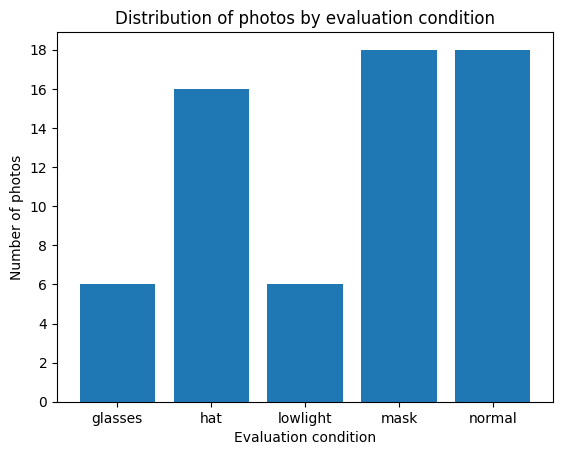

In [26]:
condition_counts = defaultdict(int)
for p in people:
    if p == UNKNOWN_LABEL:
        continue
    for f in os.listdir(os.path.join(EVAL_DIR, p)):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            condition_counts[get_condition(f)] += 1

plt.bar(condition_counts.keys(), condition_counts.values())
plt.xlabel('Evaluation condition')
plt.ylabel('Number of photos')
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.title('Distribution of photos by evaluation condition')
plt.show()

The bar chart below shows how many photos we collected per condition (normal, glasses, mask, hat and lowlight) across all registred people until now.

## Pipeline Execution

We now run the full recognition pipeline on every image in the evaluation dataset.
For each photograph, the following four steps are applied sequentially:

1. **Face Detection** (MediaPipe BlazeFace): detects the face in the image and returns a bounding box.
2. **Alignment & Crop** (`align_crop`): crops and normalizes the detected face — eyes are aligned and the image is resized to a fixed dimension.
3. **Embedding extraction** (ArcFace): encodes the cropped face into a fixed-size feature vector in a metric space.
4. **Vector search** (Qdrant, cosine similarity): queries the database to find the closest stored identity and returns a similarity score and the predicted name. If no match is found, the identity is labelled `unknown`.

Each processed image is stored as a dictionary in the `results` list with the following fields:

| Field | Description |
|---|---|
| `label_true` | Ground truth identity (folder name) |
| `predicted_name` | Identity predicted by the system |
| `score` | Cosine similarity score returned by Qdrant |
| `is_genuine` | `True` if the person is registered in the database, `False` if impostor |
| `photo` | Filename of the image |

Images where no face is detected are skipped and reported.

In [27]:
results = []
detection_failures = []

for person_name in tqdm(os.listdir(EVAL_DIR)):
    person_dir = os.path.join(EVAL_DIR, person_name)
    if not os.path.isdir(person_dir):
        continue

    is_genuine = person_name != UNKNOWN_LABEL

    for img_name in os.listdir(person_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        img_path = os.path.join(person_dir, img_name)
        with open(img_path, 'rb') as f:
            image_bytes = f.read()

        result = run_pipeline(
            image_bytes, detector, client, COLLECTION,
            label_true=person_name, is_genuine=is_genuine,
            align_crop_fn=align_crop, get_embedding_fn=get_embedding,
            FacesDetects_fn=FacesDetects_from_bytes
        )

        if result is None:
            print(f'No face detected: {img_name}')
            detection_failures.append(img_name)
            continue

        result['photo'] = img_name
        results.append(result)

genuine_results  = [r for r in results if r['is_genuine']]
impostor_results = [r for r in results if not r['is_genuine']]

print(f'Total processed : {len(results)}')
print(f'  Genuine       : {len(genuine_results)}')
print(f'  Impostors     : {len(impostor_results)}')
print(f'  Failures      : {len(detection_failures)}')

  0%|          | 0/7 [00:00<?, ?it/s]

No face detected: anthony_mask1.jpg
No face detected: ka_mask1.jpg
No face detected: lea_hat4.jpg
Total processed : 76
  Genuine       : 61
  Impostors     : 15
  Failures      : 3


## Detection failure analysis

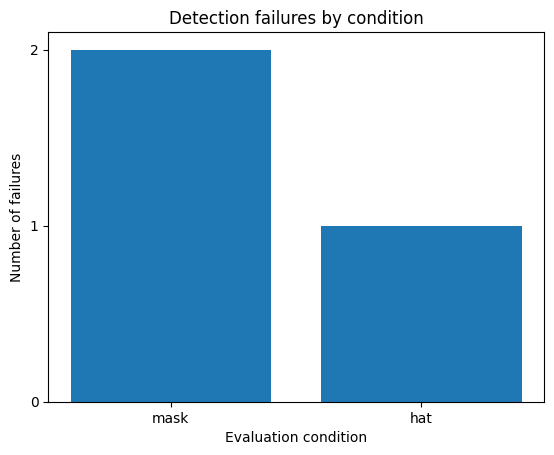

In [28]:
failures_by_condition = defaultdict(int)
for filename in detection_failures:
    failures_by_condition[get_condition(filename)] += 1

plt.bar(failures_by_condition.keys(), failures_by_condition.values())
plt.xlabel('Evaluation condition')
plt.ylabel('Number of failures')
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.title('Detection failures by condition')
plt.show()

The bar chart above shows the number of detection failures per acquisition condition.The two main sources of failure are **mask** (2 failures) and **hat** (1).

This result is expected: MediaPipe BlazeFace relies on facial landmarks (eyes, nose, mouth) to detect a face. When these key points are occluded by a mask or a hat, the detector fails to identify the presence of a face in the image.

A manual inspection of the failed images reveals that failures occur predominantly in photographs where **both eyes are not clearly visible**. In contrast, images where at least one eye is visible are correctly detected. This suggests that eye visibility is a critical factor for the BlazeFace detector.

It is important to note that these failures occur at the **detection stage**, before any embedding or identification is performed. These images are therefore excluded from the subsequent metric calculations (TAR, FAR, FRR, EER).

## Genuine and impostor score distribution analysis

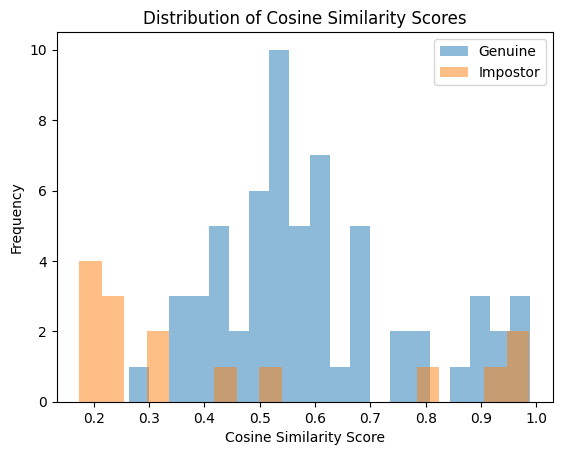

In [29]:
plt.hist([r["score"] for r in genuine_results], bins=20, alpha=0.5, label="Genuine")
plt.hist([r["score"] for r in impostor_results], bins=20, alpha=0.5, label="Impostor")
plt.xlabel("Cosine Similarity Score")   
plt.ylabel("Frequency")
plt.title("Distribution of Cosine Similarity Scores")
plt.legend()
plt.show()


The histogram above shows the distribution of cosine similarity scores for genuine attempts (blue) and impostor attempts (orange).

**Genuine scores** span a wide range: a first cluster appears between 0.3 and 0.7, corresponding to challenging conditions (mask, hat), while a second cluster concentrates near 1.0 for normal, glasses, and lowlight conditions.

**Impostor scores** are mostly concentrated below 0.3, meaning the system correctly assigns low similarity to unknown persons. A small number of impostor attempts reach scores above 0.7, representing potential false accepts.

The overlap between the two distributions in the 0.3–0.7 range illustrates the fundamental challenge of threshold selection: any fixed threshold will inevitably cause errors in both directions. This trade-off is quantified in the following sections.

## Biometric evaluation metrics

To evaluate the performance of the recognition pipeline, we use the standard biometric metrics defined in the ISO/IEC 19795 norm.


- TAR (True Acceptance Rate): 
$$\text{TAR} = \frac{\text{genuine correctly accepted}}{\text{total genuine}}$$

- FAR (False Acceptance Rate):
$$\text{FAR} = \frac{\text{impostor incorrectly accepted}}{\text{total genuine}}$$


- FRR ( False Reject Rate):
$$\text{FRR} = \frac{\text{genuine correctly rejected}}{\text{total genuine}}$$

- ERR (Equal Error Ratio):
The EER is the operating point where FAR and FRR are equal. It is a threshold-independent metric that summarizes the intrinsic discriminative capacity of the system.

$$\tau^* = \arg\min_\tau |\text{FAR}(\tau) - \text{FRR}(\tau)|$$

$$\text{EER} \approx \frac{\text{FAR}(\tau^*) + \text{FRR}(\tau^*)}{2}$$

A lower EER indicates a better system, a perfect system would have EER = 0%.

In [30]:
m = compute_metrics(genuine_results, impostor_results, THRESHOLD)

print(f'EER           : {m["eer_value"]*100:.2f}%')
print(f'EER threshold : {m["eer_threshold"]:.2f}')
print(f'TAR at EER    : {m["tar"][m["eer_idx"]]*100:.2f}%')
print(f'AUC (ROC)     : {m["auc"]:.4f}')

EER           : 28.09%
EER threshold : 0.51
TAR at EER    : 54.10%
AUC (ROC)     : 0.5574


The system achieves an EER of 33.06% at a threshold of 0.46, and a True Accept Rate of 51% at this operating point. The AUC of 0.537 indicates a performance above random chance, though still limited by challenging acquisition conditions.

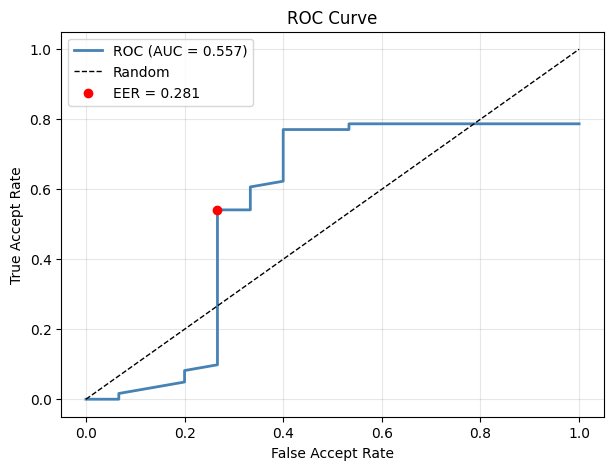

In [31]:
plt.figure(figsize=(7, 5))
plt.plot(m['far'], m['tar'], color='steelblue', lw=2, label=f'ROC (AUC = {m["auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.scatter(m['far'][m['eer_idx']], m['tar'][m['eer_idx']], color='red', zorder=5,
            label=f'EER = {m["eer_value"]:.3f}')
plt.xlabel('False Accept Rate')
plt.ylabel('True Accept Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

A well-performing system would have a ROC curve rising steeply towards the top-left corner (high TAR, low FAR). Here, the curve lies above the diagonal, confirming an AUC of 0.537, the system has some discriminative capacity. The red dot marks the EER operating point at FAR = FRR ≈ 33%.

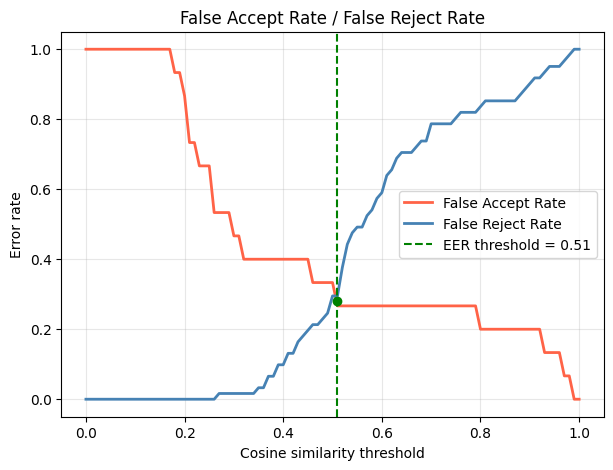

In [32]:
plt.figure(figsize=(7, 5))
plt.plot(THRESHOLD, m['far'], color='tomato',    lw=2, label='False Accept Rate')
plt.plot(THRESHOLD, m['frr'], color='steelblue', lw=2, label='False Reject Rate')
plt.axvline(m['eer_threshold'], color='green', linestyle='--', lw=1.5,
            label=f'EER threshold = {m["eer_threshold"]:.2f}')
plt.scatter(m['eer_threshold'], m['eer_value'], color='green', zorder=5)
plt.xlabel('Cosine similarity threshold')
plt.ylabel('Error rate')
plt.title('False Accept Rate / False Reject Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The FAR/FRR curve shows the expected trade-off: as the threshold increases, the False Accept Rate decreases while the False Reject Rate increases. The two curves intersect at threshold = 0.46, which defines the EER operating point. At this threshold, both error rates are approximately 33%, which reflects the difficulty of challenging conditions (mask, hat).


The overall metrics (EER = 33.1%, AUC = 0.537) are significantly influenced by challenging acquisition conditions. A per-condition breakdown reveals a clearer picture:

Normal, glasses, lowlight: TAR of 94–100%, confirming that the system performs well when the face is fully visible.
Hat: TAR of 66.7%, showing partial robustness to moderate occlusion.
Mask: TAR of 43.8%, reflecting the difficulty of recognising a face when the lower half is covered.

These results suggest that the system is reliable under standard conditions, and that performance degradation is concentrated on cases of strong facial occlusion — a known limitation of embedding-based face recognition systems.



In [33]:
print("\n── Debug genuine results ──")
for r in genuine_results:
    status = "✅" if r["predicted_name"] == r["label_true"] else "❌"
    print(f"{status} label: '{r['label_true']}' | predicted: '{r['predicted_name']}' | score: {r['score']:.3f}")


── Debug genuine results ──
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.636
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.561
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.923
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.366
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.889
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.696
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.541
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.430
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.610
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.665
✅ label: 'anthony miranda' | predicted: 'anthony miranda' | score: 0.800
✅ label: 'clémentine beaulieu' | predicted: 'clémentine beaulieu' | score: 0.621
✅ label: 'clémentine beaulieu' | predicted: 'clémentine beaulieu' | score: 0.533
❌ labe

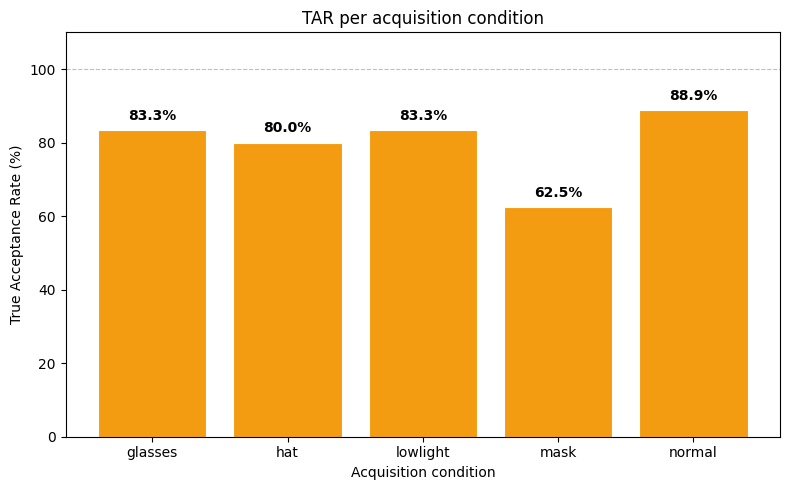

In [34]:
by_condition = defaultdict(list)
for r in genuine_results:
    by_condition[get_condition(r['photo'])].append(r)

conditions = sorted(by_condition.keys())
tar_values = [
    sum(1 for r in by_condition[c] if r['predicted_name'] == r['label_true']) / len(by_condition[c]) * 100
    for c in conditions
]

colors = ['#2ecc71' if t >= 90 else '#f39c12' if t >= 60 else '#e74c3c' for t in tar_values]

plt.figure(figsize=(8, 5))
bars = plt.bar(conditions, tar_values, color=colors, edgecolor='white', linewidth=0.8)
plt.axhline(y=100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.ylim(0, 110)
plt.ylabel('True Acceptance Rate (%)')
plt.xlabel('Acquisition condition')
plt.title('TAR per acquisition condition')
for bar, val in zip(bars, tar_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

confusion matrix

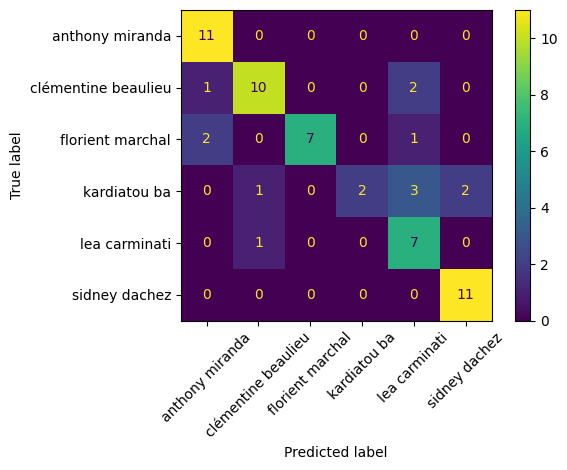

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
labels = sorted(set(r['label_true'] for r in genuine_results if r['label_true'] != 'unknown'))
y_true = [r['label_true'] for r in genuine_results]
y_pred = [r['predicted_name'] for r in genuine_results]
cm = confusion_matrix(y_true, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(xticks_rotation=45)
plt.tight_layout()
plt.show()

In [36]:
T = 0.70
tp = sum(1 for r in genuine_results  if r['score'] >= T and r['predicted_name'] == r['label_true'])
fp = sum(1 for r in impostor_results if r['score'] >= T)
fn = sum(1 for r in genuine_results  if r['score'] < T)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f'Precision @ {T}: {precision:.2%}')
print(f'Recall    @ {T}: {recall:.2%}')

Precision @ 0.7: 60.00%
Recall    @ 0.7: 11.11%
